In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\dodos\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
## Open the dataset and check the correct opening

df = pd.read_csv("swiss_communes_ml_ready.csv")
df.head()

,bfs_nr,commune_ofs,canton,join_key,premium_region,log_pop_density,pop_density_2024,is_urban,pct_hh_1p,pct_hh_2p,...,median_premium_2026,std_premium_2026,p10_premium_2026,p90_premium_2026,iqr_premium_2026,n_insurers_2026,premium_increase_pct,n_insurers_change,sa_estimated,sa_count_est
0,1,Aeugst am Albis,ZH,ZH_H3,3,5.534180,252.2,0.0,28.9,38.2,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
1,2,Affoltern am Albis,ZH,ZH_H3,3,7.104473,1216.4,1.0,36.3,32.9,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
2,3,Bonstetten,ZH,ZH_H3,3,6.646131,768.8,0.0,30.0,33.5,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
3,4,Hausen am Albis,ZH,ZH_H3,3,5.675040,290.5,0.0,30.8,35.2,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0
4,5,Hedingen,ZH,ZH_H3,3,6.419832,612.9,0.0,28.9,35.1,...,525.2,38.5,472.8,573.6,57.5,27.0,4.07,-2.0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bfs_nr                   1503 non-null   int64  
 1   commune_ofs              1503 non-null   str    
 2   canton                   1503 non-null   str    
 3   join_key                 1503 non-null   str    
 4   premium_region           1503 non-null   int64  
 5   log_pop_density          1503 non-null   float64
 6   pop_density_2024         1503 non-null   float64
 7   is_urban                 1503 non-null   float64
 8   pct_hh_1p                1503 non-null   float64
 9   pct_hh_2p                1503 non-null   float64
 10  pct_hh_3p                1503 non-null   float64
 11  pct_hh_4p                1503 non-null   float64
 12  pct_hh_5p_plus           1503 non-null   float64
 13  pct_large_hh             1503 non-null   float64
 14  pct_small_hh             1503 non-n

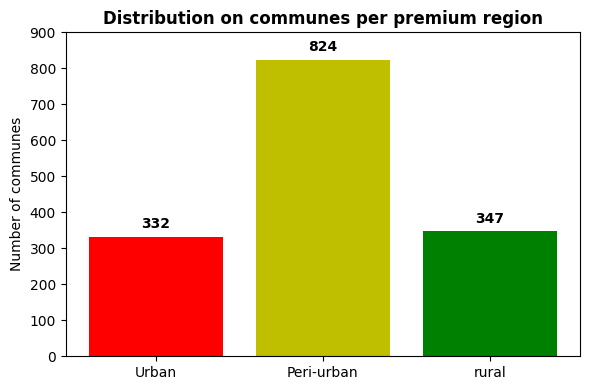

In [4]:
## SHOWING CLASS UNBALANCE:

LABELS = {1: 'Urban', 2: 'Peri-urban', 3: 'rural'}
colors = ['r', 'y', 'g']

fig, ax = plt.subplots(figsize=(6,4))
counts = df["premium_region"].value_counts().sort_index()
bars = ax.bar([LABELS[i] for i in counts.index], counts.values, color=colors)
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Distribution on communes per premium region", fontweight="heavy")
ax.set_ylabel("Number of communes")
ax.set_ylim(0, 900)
plt.tight_layout()

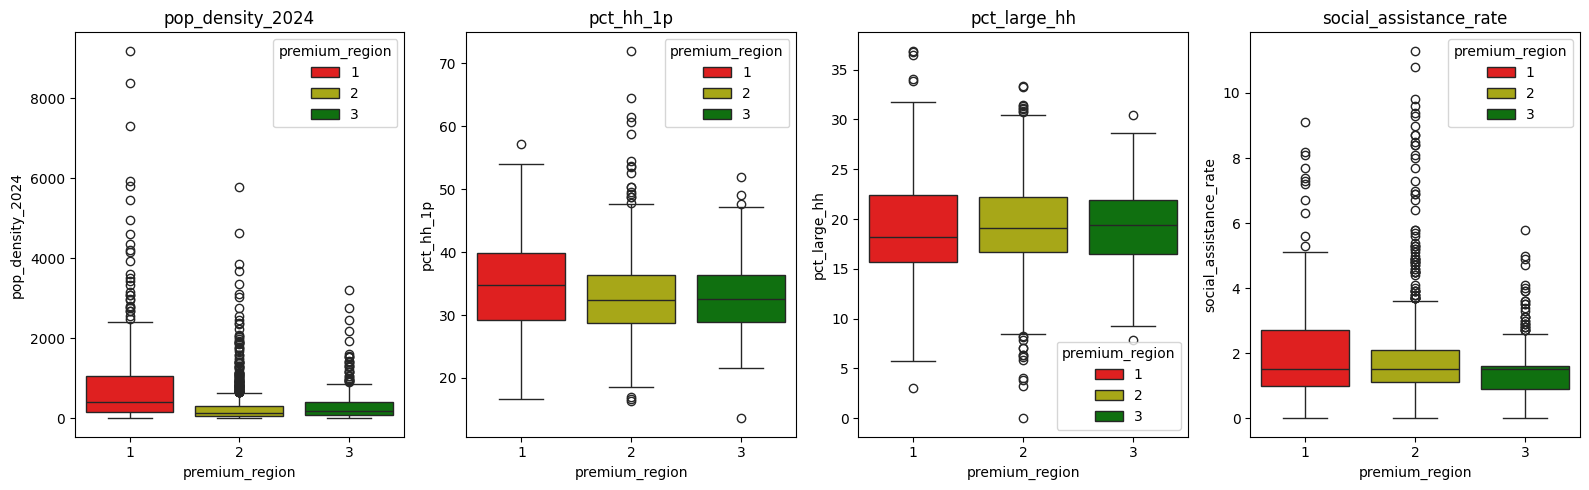

In [5]:
## BOXPLOTS SOCIO-DEMOGRAPHIQUE FEATURES VS PREMIUM REGION

sd_features = ["pop_density_2024", "pct_hh_1p", "pct_large_hh", "social_assistance_rate"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i in range(len(sd_features)):
    sns.boxplot(data=df, x="premium_region", hue="premium_region", y=sd_features[i], ax=axes[i], palette=colors)
    axes[i].set_title(sd_features[i])

plt.tight_layout()

## Anomaly Detection: Rule-based misclassification candidates

Before running any ML model, we can already identify suspicious communes using a simple rule based on population density.

The logic is the following:
- We take the 75th percentile of density among Region 3 (rural) communes → this is the "maximum typical rural density". Any Region 1 (urban) commune below this threshold is less dense than 75% of rural communes → it is paying urban prices without having an urban profile

- We take the 25th percentile of density among Region 1 (urban) communes → this is the "minimum typical urban density". Any Region 3 (rural) commune above this threshold is denser than 75% of urban communes → it is paying rural prices without having a rural profile

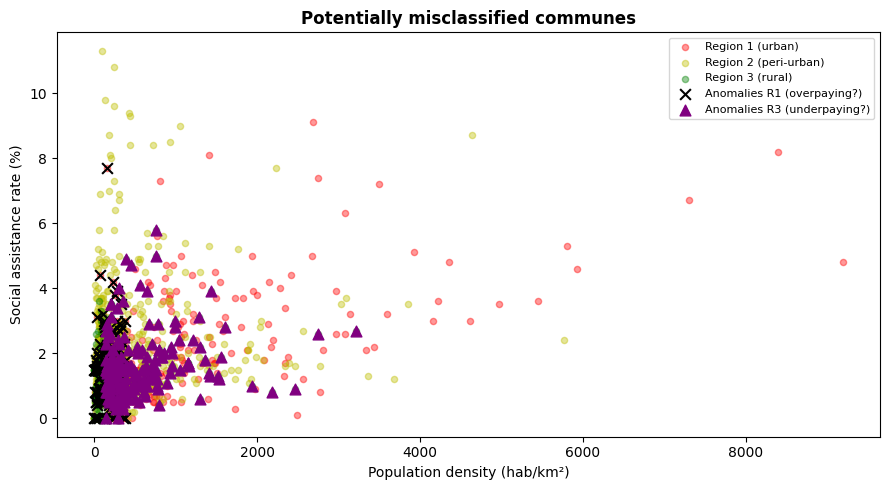

In [6]:
# POTENTIAL MISCLASSIFICATION

r3_density_p75 = df[df['premium_region'] == 3]['pop_density_2024'].quantile(0.75)
r1_density_p25 = df[df['premium_region'] == 1]['pop_density_2024'].quantile(0.25)

anomali_r1 = df[(df['premium_region'] == 1) & (df['pop_density_2024'] < r3_density_p75)]
anomali_r3 = df[(df['premium_region'] == 3) & (df['pop_density_2024'] > r1_density_p25)]

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['r', 'y', 'g']
labels = ['Region 1 (urban)', 'Region 2 (peri-urban)', 'Region 3 (rural)']

for i, r in enumerate([1, 2, 3]):
    sub = df[df['premium_region'] == r]
    ax.scatter(sub['pop_density_2024'], sub['social_assistance_rate'],
               color=colors[i], alpha=0.4, s=20, label=labels[i])

ax.scatter(anomali_r1['pop_density_2024'], anomali_r1['social_assistance_rate'],
           color='black', marker='x', s=60, linewidths=1.5, label='Anomalies R1 (overpaying?)')
ax.scatter(anomali_r3['pop_density_2024'], anomali_r3['social_assistance_rate'],
           color='purple', marker='^', s=60, label='Anomalies R3 (underpaying?)')

ax.set_xlabel('Population density (hab/km²)')
ax.set_ylabel('Social assistance rate (%)')
ax.set_title('Potentially misclassified communes', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('eda_anomalies.png', dpi=150)

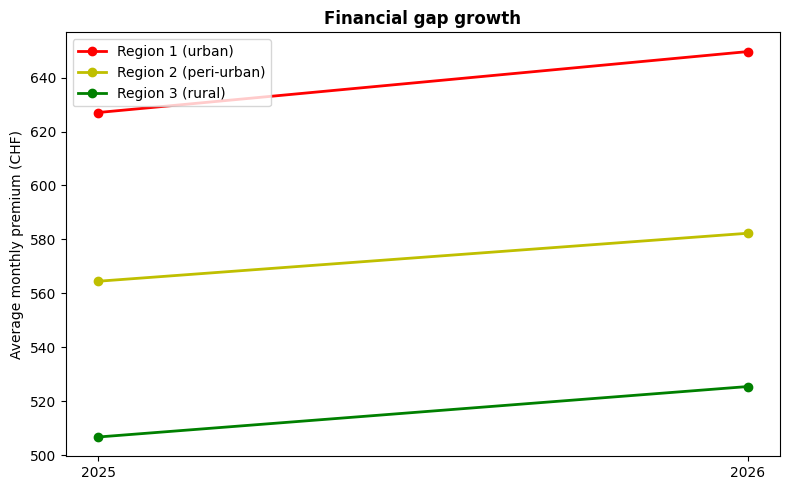

In [7]:
gap = df.groupby('premium_region')[['avg_premium_2025', 'avg_premium_2026']].mean()

fig, ax = plt.subplots(figsize=(8, 5))

x = [0, 1]  # 2025 and 2026

for i, r in enumerate([1, 2, 3]):
    ax.plot(x, [gap.loc[r, 'avg_premium_2025'], gap.loc[r, 'avg_premium_2026']],
            color=colors[i], marker='o', linewidth=2, label=labels[i])

ax.set_xticks([0, 1])
ax.set_xticklabels(['2025', '2026'])
ax.set_ylabel('Average monthly premium (CHF)')
ax.set_title('Financial gap growth', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150)

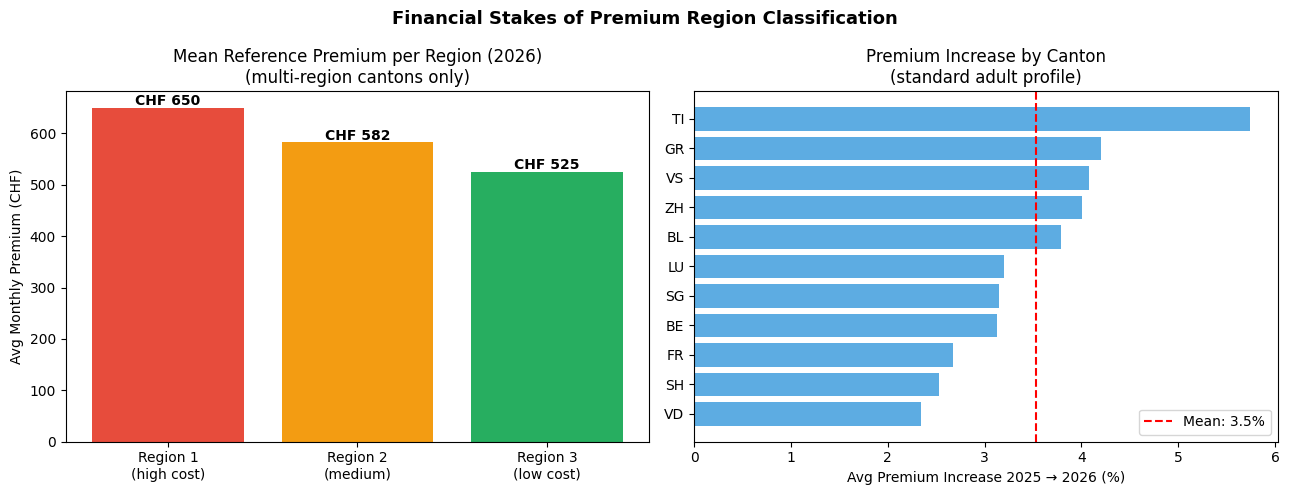

In [8]:
FEATURES_OFS = [c for c in [
    'log_pop_density', 'pop_density_2024', 'is_urban',
    'pct_hh_1p', 'pct_hh_2p', 'pct_hh_3p', 'pct_hh_4p', 'pct_hh_5p_plus',
    'pct_large_hh', 'pct_small_hh',
    'social_assistance_rate', 'social_assistance_count'
] if c in df.columns]

FEATURES_ALL = [c for c in FEATURES_OFS + [
    'avg_premium_2025', 'avg_premium_2026',
    'median_premium_2026', 'std_premium_2026',
    'p10_premium_2026', 'p90_premium_2026', 'iqr_premium_2026',
    'n_insurers_2026', 'premium_increase_pct'
] if c in df.columns]

y = df['premium_region'].values

# Plot
multi_region = df[df['join_key'].str.contains('_H[123]', regex=True)]
avg_by_region = multi_region.groupby('premium_region')['avg_premium_2026'].mean()
canton_increase = df.groupby('canton')['premium_increase_pct'].mean().dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Financial Stakes of Premium Region Classification', fontsize=13, fontweight='bold')

bars = axes[0].bar(['Region 1\n(high cost)', 'Region 2\n(medium)', 'Region 3\n(low cost)'],
                    avg_by_region.values, color=['#e74c3c', '#f39c12', '#27ae60'])
for bar, val in zip(bars, avg_by_region.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'CHF {val:.0f}', ha='center', fontweight='bold')
axes[0].set_ylabel('Avg Monthly Premium (CHF)')
axes[0].set_title('Mean Reference Premium per Region (2026)\n(multi-region cantons only)')

axes[1].barh(canton_increase.index, canton_increase.values, color='#3498db', alpha=0.8)
axes[1].axvline(canton_increase.mean(), color='red', linestyle='--',
                label=f'Mean: {canton_increase.mean():.1f}%')
axes[1].set_xlabel('Avg Premium Increase 2025 → 2026 (%)')
axes[1].set_title('Premium Increase by Canton\n(standard adult profile)')
axes[1].legend()

plt.tight_layout()
plt.show()

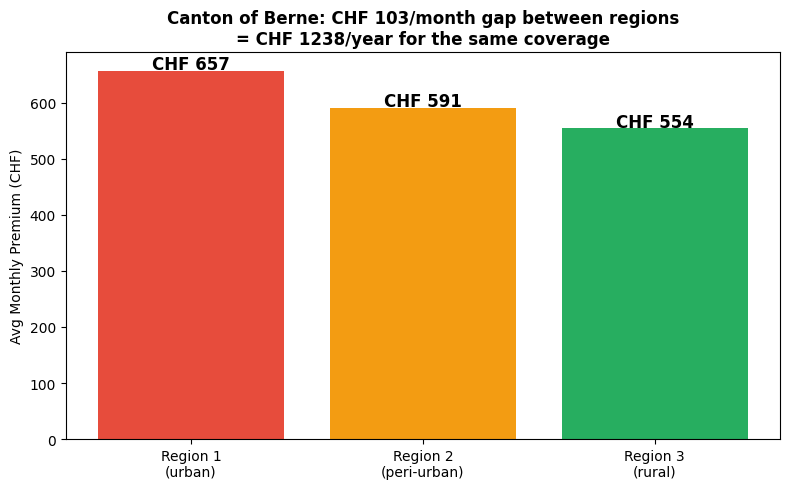

In [9]:
# Filter Berne multi-region communes
berne = df[df['canton'] == 'BE'].groupby('premium_region')['avg_premium_2026'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax.bar(['Region 1\n(urban)', 'Region 2\n(peri-urban)', 'Region 3\n(rural)'],
               berne.values, color=colors)

for bar, val in zip(bars, berne.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'CHF {val:.0f}', ha='center', fontweight='bold', fontsize=12)

gap = berne.values[0] - berne.values[2]
ax.set_ylabel('Avg Monthly Premium (CHF)')
ax.set_title(f'Canton of Berne: CHF {gap:.0f}/month gap between regions\n'
             f'= CHF {gap*12:.0f}/year for the same coverage',
             fontweight='bold')

plt.tight_layout()
plt.show()

## MULTICOLLINEARITY

From the correlation heatmap, we can see that some variable are correlated between each others, making the dataset a little bit redundant. Instead of keeping all the variables, some can be eliminated from the dataset. In the code that follow, we calculated the VIF (Variance inflation Factor), to demonstrate quantitatively what the correlation heatmap already suggests us. Note tha the VIF can be calculated only on numerical variables, hence we are going to consider only those.

In [10]:
!pip install statsmodels

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = ['log_pop_density', 'pop_density_2024', 'pct_hh_1p', 'pct_large_hh',
            'social_assistance_rate', 'avg_premium_2025', 'avg_premium_2026',
            'median_premium_2026', 'p10_premium_2026', 'p90_premium_2026',
            'n_insurers_2026', 'premium_increase_pct']

X = df[features]

vif_data = pd.DataFrame()
vif_data['feature'] = features
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]

print(vif_data.sort_values('VIF', ascending=False))

                   feature           VIF
6         avg_premium_2026  1.365867e+06
5         avg_premium_2025  1.087841e+06
7      median_premium_2026  9.240413e+04
8         p10_premium_2026  2.504048e+04
9         p90_premium_2026  2.101187e+04
11    premium_increase_pct  1.651782e+03
10         n_insurers_2026  3.407626e+02
2                pct_hh_1p  8.220244e+01
3             pct_large_hh  4.955618e+01
0          log_pop_density  3.535461e+01
4   social_assistance_rate  3.920821e+00
1         pop_density_2024  3.123629e+00


---

**UNSUPERVISED LEARNING**

---
**PCA**

In [12]:
from sklearn.preprocessing import StandardScaler

X_ofs = df[FEATURES_OFS].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_ofs)

pd.DataFrame(X_scaled, columns=FEATURES_OFS).describe() ## Scaling worked fine --> Mean around 0 and std around 1

,log_pop_density,pop_density_2024,is_urban,pct_hh_1p,pct_hh_2p,pct_hh_3p,pct_hh_4p,pct_hh_5p_plus,pct_large_hh,pct_small_hh,social_assistance_rate,social_assistance_count
count,1.503000e+03,1.503000e+03,1.503000e+03,1.503000e+03,1.503000e+03,1.503000e+03,1.503000e+03,1503.000000,1.503000e+03,1.503000e+03,1.503000e+03,1.503000e+03
mean,-5.483896e-16,-8.982243e-17,-4.254747e-17,7.847644e-16,-1.890999e-16,3.592897e-16,-3.498347e-16,0.000000,-4.018372e-16,-4.112922e-16,-4.727497e-17,-7.091245e-18
std,1.000333e+00,1.000333e+00,1.000333e+00,1.000333e+00,1.000333e+00,1.000333e+00,1.000333e+00,1.000333,1.000333e+00,1.000333e+00,1.000333e+00,1.000333e+00
min,-3.185854e+00,-5.633331e-01,-3.511672e-01,-2.979516e+00,-3.163261e+00,-4.555020e+00,-3.866379e+00,-2.720152,-4.184099e+00,-4.521579e+00,-1.272753e+00,-1.895983e-01
25%,-5.795780e-01,-4.680435e-01,-3.511672e-01,-6.741485e-01,-7.082079e-01,-6.400682e-01,-6.330963e-01,-0.652572,-6.067826e-01,-6.241057e-01,-5.566312e-01,-1.895983e-01
50%,-1.670335e-02,-3.472217e-01,-3.511672e-01,-6.747298e-02,-3.427171e-02,-8.078937e-02,-5.572427e-02,-0.088686,-3.964709e-02,4.895182e-02,-1.985702e-01,-1.605797e-01
75%,6.557185e-01,6.059803e-03,-3.511672e-01,5.847032e-01,6.396645e-01,5.483993e-01,6.082535e-01,0.522190,6.147400e-01,6.280944e-01,2.311030e-01,-8.461920e-02
max,2.781445e+00,1.140421e+01,2.847647e+00,5.877947e+00,3.913069e+00,7.364610e+00,3.754931e+00,4.610360,3.864863e+00,4.416000e+00,6.819426e+00,2.538605e+01


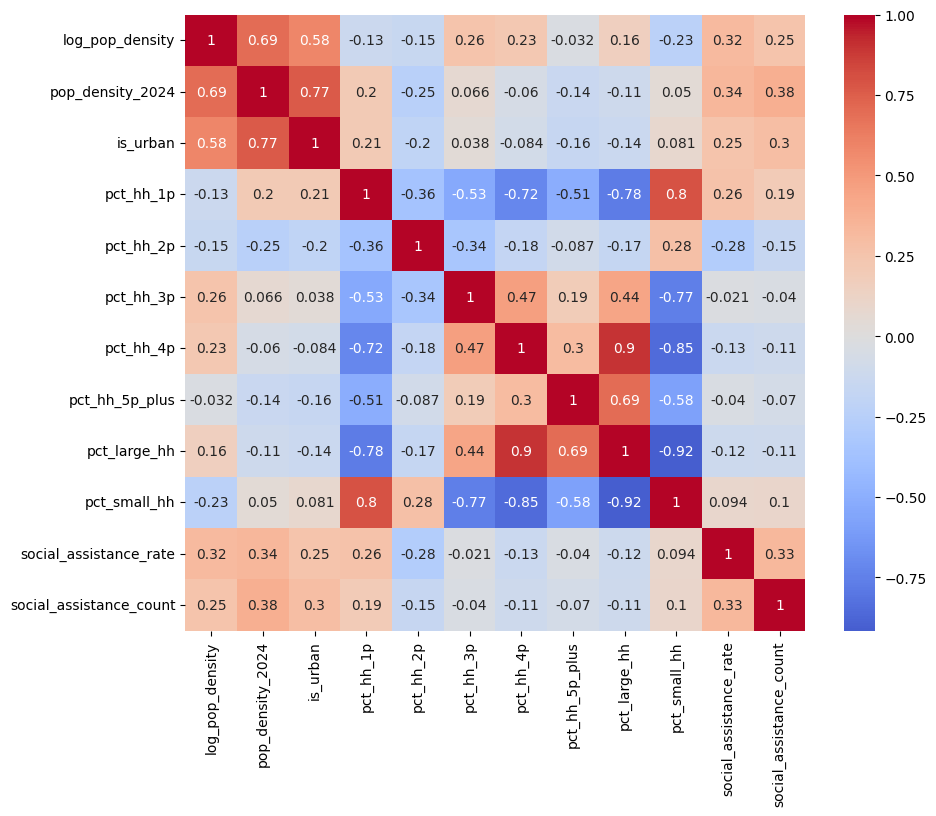

In [13]:
## Show correlation between features

plt.figure(figsize=(10, 8))
sns.heatmap(df[FEATURES_OFS].corr(), annot=True, cmap="coolwarm", center=0);
plt.show()

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 12)
pca_result = pca.fit(X_scaled)
df_pca = pd.DataFrame(pca.transform(X_scaled))
df_pca

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.533289,-0.594154,0.937081,0.088354,0.295401,0.119378,-0.065090,0.269370,-0.054205,0.000224,8.652208e-16,-5.397904e-16
1,0.871346,2.778151,0.790363,-0.131576,-1.060339,-0.193424,-0.187080,-0.751878,-1.015600,-0.000283,6.029463e-16,-1.476692e-16
2,-1.403739,0.655971,0.482561,-0.872732,0.417368,-0.105498,0.747452,0.741745,0.185319,0.000289,-2.462420e-17,-3.934036e-16
3,-0.794394,-0.254833,0.268586,0.182462,-0.109737,-0.053353,0.123918,0.453424,-0.120213,-0.015529,-1.768676e-14,4.510498e-15
4,-1.354664,0.303238,0.589507,-0.203283,0.139155,0.024168,0.172816,0.695242,0.062008,-0.015199,-1.781263e-14,4.398792e-15
...,...,...,...,...,...,...,...,...,...,...,...,...
1498,-0.201029,-1.478743,0.748904,0.009053,0.745264,0.101262,0.463340,-0.972198,0.405180,0.000311,1.057872e-15,-1.583059e-16
1499,0.891364,0.620274,-0.428638,-0.016256,-0.262381,0.132131,0.082552,1.138499,-0.133401,0.015133,1.698107e-14,-4.160110e-15
1500,-0.195322,-1.108158,-0.629027,0.003453,-0.134555,-0.384890,1.570449,-0.791905,0.310690,0.014869,1.732033e-14,-4.673489e-15
1501,-1.156560,-1.076656,-0.307744,-0.673367,0.197434,-0.770007,-2.672495,0.035079,0.038986,0.000362,6.095213e-16,-9.945303e-16


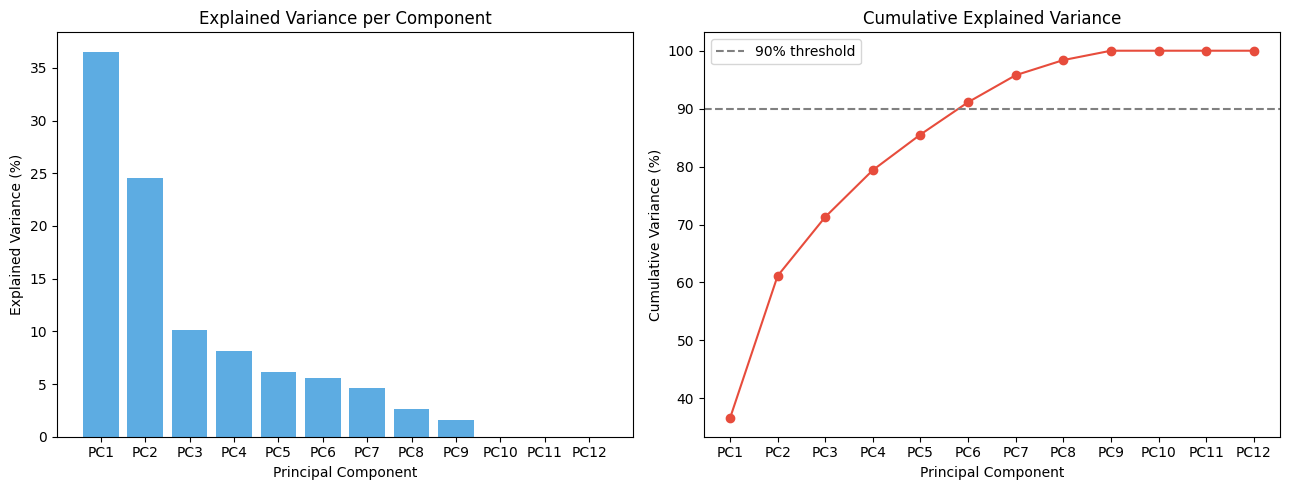

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

explained = pca.explained_variance_ratio_ * 100
cumulative = explained.cumsum()
components = [f'PC{i+1}' for i in range(len(explained))]

axes[0].bar(components, explained, color='#3498db', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Explained Variance per Component')

axes[1].plot(components, cumulative, marker='o', color='#e74c3c')
axes[1].axhline(90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

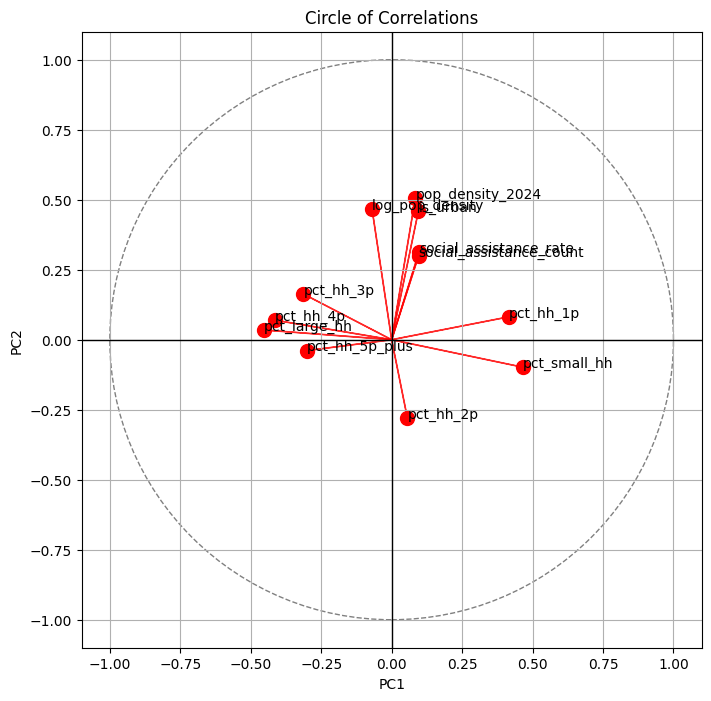

In [16]:
loading_matrix = pd.DataFrame(pca.components_.T, 
                               columns=[f'PC{i+1}' for i in range(len(FEATURES_OFS))], 
                               index=FEATURES_OFS).iloc[:, :2]

loading_matrix_normalized = loading_matrix / np.sqrt(np.sum(loading_matrix**2, axis=0))

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(loading_matrix_normalized['PC1'], loading_matrix_normalized['PC2'], color='r', marker='o', s=100)
for feature in loading_matrix_normalized.index:
    ax.arrow(0, 0, loading_matrix_normalized.loc[feature, 'PC1'], loading_matrix_normalized.loc[feature, 'PC2'],
             color='r', alpha=0.8)
    ax.text(loading_matrix_normalized.loc[feature, 'PC1'], loading_matrix_normalized.loc[feature, 'PC2'],
            feature, color='black', fontsize=10)

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.add_artist(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1))
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Circle of Correlations')
ax.grid()
plt.show()

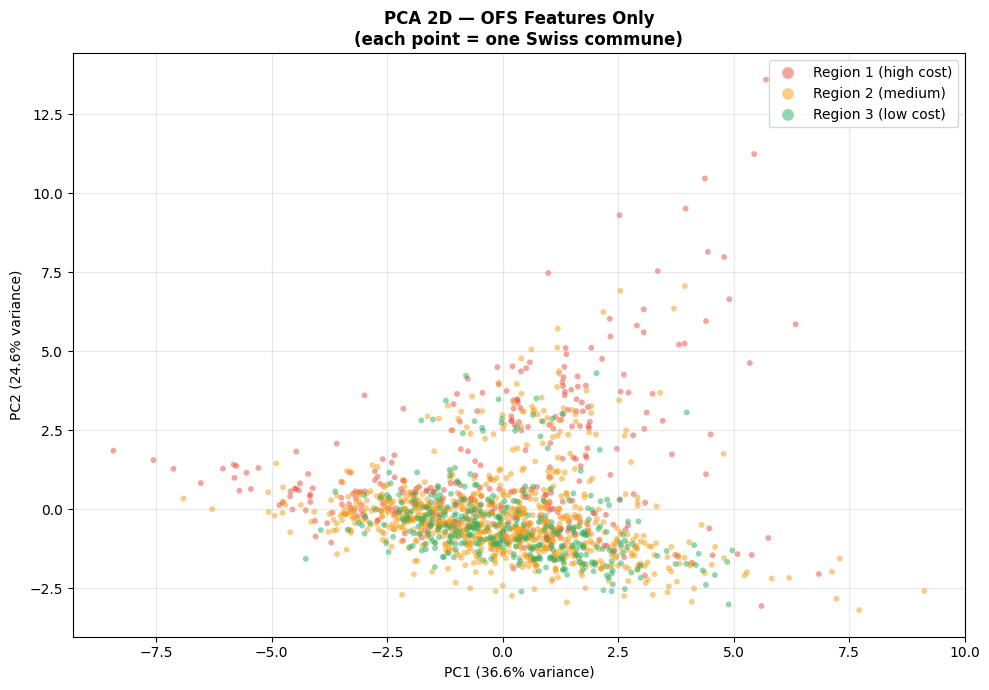

In [17]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

palette  = {1: '#e74c3c', 2: '#f39c12', 3: '#27ae60'}
reg_lbls = {1: 'Region 1 (high cost)', 2: 'Region 2 (medium)', 3: 'Region 3 (low cost)'}

fig, ax = plt.subplots(figsize=(10, 7))
for r in [1, 2, 3]:
    mask = y == r
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=palette[r], label=reg_lbls[r],
               alpha=0.5, s=18, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA 2D — OFS Features Only\n(each point = one Swiss commune)', fontweight='bold')
ax.legend(markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

**K-MEANS CLUSTERING**

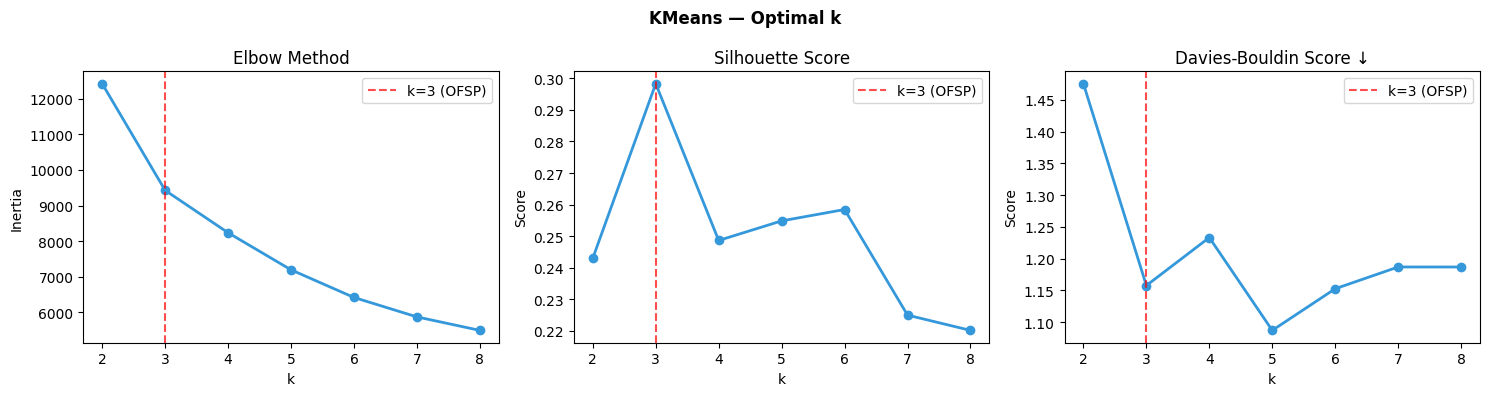

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

n_90 = 6  ## Number of components to explain 90% of the Variance ( from the cumulative explained variance plot above)
pca_n = PCA(n_components=n_90, random_state=42)
X_pcaN = pca_n.fit_transform(X_scaled)

k_range = range(2, 9)
sil, db, inertia = [], [], []
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pcaN)
    sil.append(silhouette_score(X_pcaN, lbl))
    db.append(davies_bouldin_score(X_pcaN, lbl))
    inertia.append(km.inertia_)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('KMeans — Optimal k', fontweight='bold')
for ax, vals, title, ylabel in zip(
    axes,
    [inertia, sil, db],
    ['Elbow Method', 'Silhouette Score', 'Davies-Bouldin Score ↓'],
    ['Inertia', 'Score', 'Score']
):
    ax.plot(k_range, vals, 'o-', lw=2, color='#3498db')
    ax.axvline(3, color='red', ls='--', alpha=0.7, label='k=3 (OFSP)')
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()
    

Silhouette score: 0.298


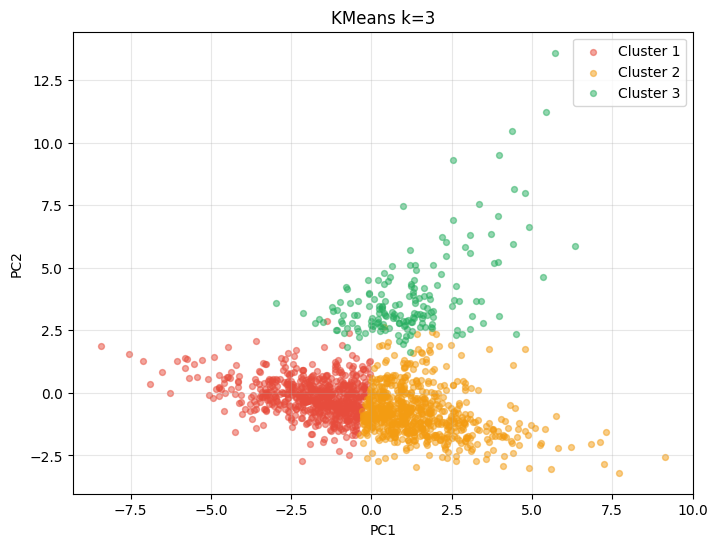

In [19]:
from sklearn.metrics import silhouette_score

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km3.fit_predict(X_pcaN)

print(f'Silhouette score: {silhouette_score(X_pcaN, clusters):.3f}') ## --> Pretty low silhouette score: coherent

colors = ['#e74c3c', '#f39c12', '#27ae60']

fig, ax = plt.subplots(figsize=(8, 6))
for c in [0, 1, 2]:
    mask = clusters == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[c], label=f'Cluster {c+1}', alpha=0.5, s=18)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('KMeans k=3')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

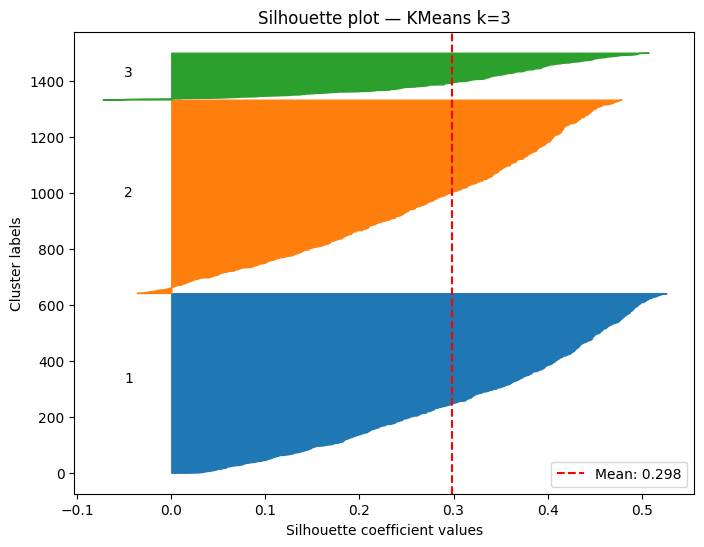

In [20]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_pcaN, clusters)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 0
for c in [0, 1, 2]:
    vals = np.sort(sil_vals[clusters == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(range(y_lower, y_upper), 0, vals, color=colors[c])
    ax.text(-0.05, (y_lower + y_upper) / 2, str(c+1))
    y_lower = y_upper

ax.axvline(sil_vals.mean(), color='red', ls='--', label=f'Mean: {sil_vals.mean():.3f}')
ax.set_xlabel('Silhouette coefficient values')
ax.set_ylabel('Cluster labels')
ax.set_title('Silhouette plot — KMeans k=3')
ax.legend()
plt.show()

In [71]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from scipy.optimize import linear_sum_assignment


km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km3.fit_predict(X_pcaN)


conf = confusion_matrix(y - 1, clusters)
row_ind, col_ind = linear_sum_assignment(-conf)

mapping = {col_ind[i]: row_ind[i] + 1 for i in range(3)}
clusters_aligned = [mapping[c] for c in clusters]

agreement = (clusters_aligned == y).mean()
kappa = cohen_kappa_score(y, clusters_aligned)

print(f'Agreement: {agreement:.1%}')
print(f'Cohen’s Kappa: {kappa:.4f}')

Agreement: 43.1%
Cohen’s Kappa: 0.0885


---

**SUPERVISED LEARNING**

---

In [51]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer

FEATURES_PREMIUM = [
    'avg_premium_2025', 'avg_premium_2026',
    'median_premium_2026', 'std_premium_2026',
    'p10_premium_2026', 'p90_premium_2026', 'iqr_premium_2026',
    'n_insurers_2026', 'premium_increase_pct'
]

FEATURES_ALL = [c for c in FEATURES_OFS + FEATURES_PREMIUM if c in df.columns]

y = df['premium_region'].values

# Experiment A — full features (circular, sanity check)
X_all = df[FEATURES_ALL].values
X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, random_state=42, stratify=y
)
sc_all = StandardScaler()
X_tr_all = sc_all.fit_transform(X_tr_all)
X_te_all = sc_all.transform(X_te_all)

# Experiment B — OFS only (main model)
X_ofs = df[FEATURES_OFS].values
X_tr_ofs, X_te_ofs, _, _ = train_test_split(
    X_ofs, y, test_size=0.20, random_state=42, stratify=y
)
sc_ofs = StandardScaler()
X_tr_ofs = sc_ofs.fit_transform(X_tr_ofs)
X_te_ofs = sc_ofs.transform(X_te_ofs)

kappa_scorer = make_scorer(cohen_kappa_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {len(y_train)} communes')
print(f'Test:  {len(y_test)} communes')

Train: 1202 communes
Test:  301 communes


**PART 1**

We first run a logistic regression, a random forest, aXGBoost model and a SVM on the full dataset. This serves as a diagnostic step to expose a fundamental issue: Premium features are directly determined at the regional level by insurers, meaning they encode the regional label by construction. Using them as predictors creates a circular model that learns the administrative definition rather than any meaningful demographic signal. This circularity produces artificially inflated performance, making the model appear nearly perfect while remaining scientifically useless.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score,balanced_accuracy_score

gs_lr_A = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1, 10]},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_lr_A.fit(X_tr_all, y_train)
y_pred_lr_A = gs_lr_A.predict(X_te_all)

print(f'Accuracy:          {(y_test == y_pred_lr_A).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_lr_A):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_lr_A):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_lr_A, average="macro"):.3f}')

Accuracy:          0.870
Balanced Accuracy: 0.889
Cohen Kappa:       0.790
Macro-F1:          0.868


In [53]:
from sklearn.ensemble import RandomForestClassifier

gs_rf_A = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    {'n_estimators': [200, 500],
     'max_depth': [10, 20, None],
     'min_samples_split': [2, 5]},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_rf_A.fit(X_tr_all, y_train)
y_pred_rf_A = gs_rf_A.predict(X_te_all)

print(f'Accuracy:          {(y_test == y_pred_rf_A).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_rf_A):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_rf_A):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_rf_A, average="macro"):.3f}')

Accuracy:          1.000
Balanced Accuracy: 1.000
Cohen Kappa:       1.000
Macro-F1:          1.000


In [54]:
!pip install xgboost
from xgboost import XGBClassifier

gs_xgb_A = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
    {'n_estimators': [200, 500],
     'max_depth': [4, 6],
     'learning_rate': [0.05, 0.1]},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_xgb_A.fit(X_tr_all, y_train - 1)
y_pred_xgb_A = gs_xgb_A.predict(X_te_all) + 1

print(f'Accuracy:          {(y_test == y_pred_xgb_A).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_xgb_A):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_xgb_A):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_xgb_A, average="macro"):.3f}')

Accuracy:          1.000
Balanced Accuracy: 1.000
Cohen Kappa:       1.000
Macro-F1:          1.000


In [55]:
from sklearn.svm import SVC

gs_svm_A = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_svm_A.fit(X_tr_all, y_train)
y_pred_svm_A = gs_svm_A.predict(X_te_all)

print(f'Accuracy:          {(y_test == y_pred_svm_A).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_svm_A):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_svm_A):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_svm_A, average="macro"):.3f}')

Accuracy:          0.983
Balanced Accuracy: 0.984
Cohen Kappa:       0.972
Macro-F1:          0.982


---

**PART 2**

Now we are going to train the same exact models, but using solely the socio-demographique features, to show the misclassification.


In [56]:
gs_lr_B = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1, 10]},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_lr_B.fit(X_tr_ofs, y_train)
y_pred_lr_B = gs_lr_B.predict(X_te_ofs)

print(f'Accuracy:          {(y_test == y_pred_lr_B).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_lr_B):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_lr_B):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_lr_B, average="macro"):.3f}')

Accuracy:          0.482
Balanced Accuracy: 0.540
Cohen Kappa:       0.239
Macro-F1:          0.485


In [72]:
coef_df = pd.DataFrame(
    gs_lr_B.best_estimator_.coef_,
    columns=FEATURES_OFS,
    index=['Region 1', 'Region 2', 'Region 3']
).T

print(coef_df)

                         Region 1  Region 2  Region 3
log_pop_density          0.218103 -0.432465  0.214362
pop_density_2024        -0.024720  0.036480 -0.011760
is_urban                 0.058328  0.005359 -0.063688
pct_hh_1p                0.241540 -0.156705 -0.084835
pct_hh_2p               -0.640232  0.245722  0.394510
pct_hh_3p                0.640140 -0.070981 -0.569159
pct_hh_4p                0.120004  0.062376 -0.182381
pct_hh_5p_plus          -0.479400 -0.027464  0.506864
pct_large_hh            -0.133147  0.034221  0.098926
pct_small_hh            -0.171682 -0.000007  0.171689
social_assistance_rate  -0.108043  0.313039 -0.204995
social_assistance_count  0.343307 -0.000021 -0.343285


In [58]:
gs_rf_B = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    {'n_estimators': [200, 500],
     'max_depth': [10, 20, None],
     'min_samples_split': [2, 5]},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_rf_B.fit(X_tr_ofs, y_train)
y_pred_rf_B = gs_rf_B.predict(X_te_ofs)

print(f'Accuracy:          {(y_test == y_pred_rf_B).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_rf_B):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_rf_B):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_rf_B, average="macro"):.3f}')

Accuracy:          0.598
Balanced Accuracy: 0.580
Cohen Kappa:       0.334
Macro-F1:          0.578


In [59]:
gs_xgb_B = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
    {'n_estimators': [200, 500],
     'max_depth': [4, 6],
     'learning_rate': [0.05, 0.1]},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_xgb_B.fit(X_tr_ofs, y_train - 1)
y_pred_xgb_B = gs_xgb_B.predict(X_te_ofs) + 1

print(f'Accuracy:          {(y_test == y_pred_xgb_B).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_xgb_B):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_xgb_B):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_xgb_B, average="macro"):.3f}')

Accuracy:          0.588
Balanced Accuracy: 0.532
Cohen Kappa:       0.284
Macro-F1:          0.540


In [60]:
gs_svm_B = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    cv=cv, scoring=kappa_scorer, n_jobs=-1
)
gs_svm_B.fit(X_tr_ofs, y_train)
y_pred_svm_B = gs_svm_B.predict(X_te_ofs)

print(f'Accuracy:          {(y_test == y_pred_svm_B).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_svm_B):.3f}')
print(f'Cohen Kappa:       {cohen_kappa_score(y_test, y_pred_svm_B):.3f}')
print(f'Macro-F1:          {f1_score(y_test, y_pred_svm_B, average="macro"):.3f}')

Accuracy:          0.565
Balanced Accuracy: 0.622
Cohen Kappa:       0.349
Macro-F1:          0.569


In [61]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'] * 2,
    'Experiment': ['A (Full)']*4 + ['B (OFS only)']*4,
    'Accuracy': [
        (y_test == y_pred_lr_A).mean(),  (y_test == y_pred_rf_A).mean(),
        (y_test == y_pred_xgb_A).mean(), (y_test == y_pred_svm_A).mean(),
        (y_test == y_pred_lr_B).mean(),  (y_test == y_pred_rf_B).mean(),
        (y_test == y_pred_xgb_B).mean(), (y_test == y_pred_svm_B).mean(),
    ],
    'Balanced Acc': [
        balanced_accuracy_score(y_test, y_pred_lr_A),  balanced_accuracy_score(y_test, y_pred_rf_A),
        balanced_accuracy_score(y_test, y_pred_xgb_A), balanced_accuracy_score(y_test, y_pred_svm_A),
        balanced_accuracy_score(y_test, y_pred_lr_B),  balanced_accuracy_score(y_test, y_pred_rf_B),
        balanced_accuracy_score(y_test, y_pred_xgb_B), balanced_accuracy_score(y_test, y_pred_svm_B),
    ],
    'Cohen Kappa': [
        cohen_kappa_score(y_test, y_pred_lr_A),  cohen_kappa_score(y_test, y_pred_rf_A),
        cohen_kappa_score(y_test, y_pred_xgb_A), cohen_kappa_score(y_test, y_pred_svm_A),
        cohen_kappa_score(y_test, y_pred_lr_B),  cohen_kappa_score(y_test, y_pred_rf_B),
        cohen_kappa_score(y_test, y_pred_xgb_B), cohen_kappa_score(y_test, y_pred_svm_B),
    ],
    'Macro-F1': [
        f1_score(y_test, y_pred_lr_A,  average='macro'), f1_score(y_test, y_pred_rf_A,  average='macro'),
        f1_score(y_test, y_pred_xgb_A, average='macro'), f1_score(y_test, y_pred_svm_A, average='macro'),
        f1_score(y_test, y_pred_lr_B,  average='macro'), f1_score(y_test, y_pred_rf_B,  average='macro'),
        f1_score(y_test, y_pred_xgb_B, average='macro'), f1_score(y_test, y_pred_svm_B, average='macro'),
    ]
}).round(3)

print(results.to_string(index=False))

              Model   Experiment  Accuracy  Balanced Acc  Cohen Kappa  Macro-F1
Logistic Regression     A (Full)     0.870         0.889        0.790     0.868
      Random Forest     A (Full)     1.000         1.000        1.000     1.000
            XGBoost     A (Full)     1.000         1.000        1.000     1.000
                SVM     A (Full)     0.983         0.984        0.972     0.982
Logistic Regression B (OFS only)     0.482         0.540        0.239     0.485
      Random Forest B (OFS only)     0.598         0.580        0.334     0.578
            XGBoost B (OFS only)     0.588         0.532        0.284     0.540
                SVM B (OFS only)     0.565         0.622        0.349     0.569


In [69]:
from sklearn.metrics import cohen_kappa_score, balanced_accuracy_score

models_B = {
    'Logistic Regression': (gs_lr_B, X_tr_ofs, X_te_ofs),
    'Random Forest':       (gs_rf_B, X_tr_ofs, X_te_ofs),
    'XGBoost':             (gs_xgb_B, X_tr_ofs, X_te_ofs),
    'SVM':                 (gs_svm_B, X_tr_ofs, X_te_ofs),
}

print(f"{'Model':<25} {'Train Kappa':>12} {'Test Kappa':>12} {'Gap Kappa':>10} {'Train BalAcc':>13} {'Test BalAcc':>12}")
print("-" * 85)
for name, (gs, X_tr, X_te) in models_B.items():
    y_tr_pred = gs.predict(X_tr)
    y_te_pred = gs.predict(X_te)

    if name == 'XGBoost':
        y_tr_pred = y_tr_pred + 1
        y_te_pred = y_te_pred + 1

    train_kappa = cohen_kappa_score(y_train, y_tr_pred)
    test_kappa  = cohen_kappa_score(y_test,  y_te_pred)
    train_bal   = balanced_accuracy_score(y_train, y_tr_pred)
    test_bal    = balanced_accuracy_score(y_test,  y_te_pred)

    print(f"{name:<25} {train_kappa:>12.3f} {test_kappa:>12.3f} {train_kappa-test_kappa:>10.3f} {train_bal:>13.3f} {test_bal:>12.3f}")

Model                      Train Kappa   Test Kappa  Gap Kappa  Train BalAcc  Test BalAcc
-------------------------------------------------------------------------------------
Logistic Regression              0.310        0.239      0.072         0.604        0.540
Random Forest                    0.896        0.334      0.563         0.949        0.580
XGBoost                          0.958        0.284      0.674         0.969        0.532
SVM                              0.554        0.349      0.205         0.768        0.622


**INTERPRETATION**

Due to the class imbalance, we can either look at the Balanced accuracy, either to the Cohen's kappa. By looking at these two metrics, we can choose from two different models: SVM and random forest.
The final decision is SVM , due to lower overfitting.

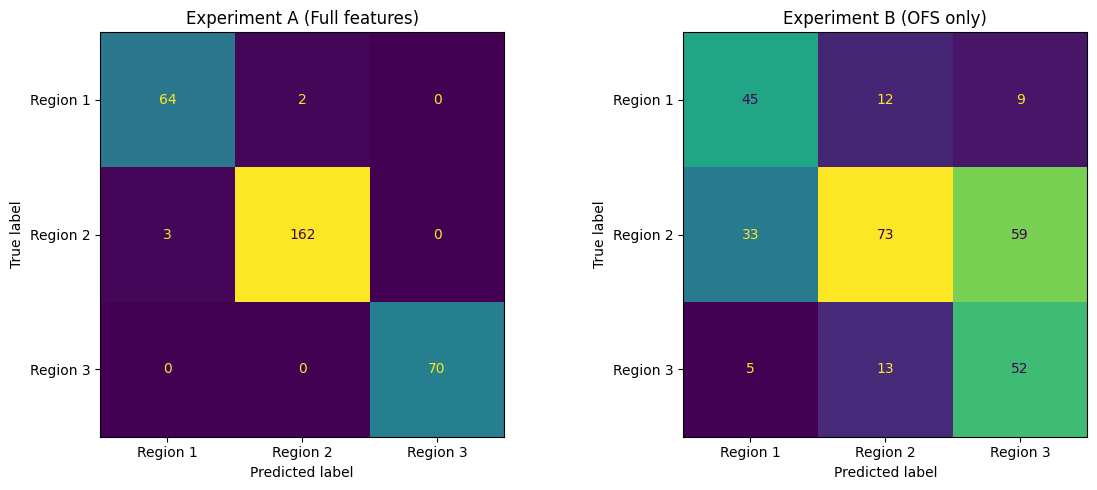

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_svm_A, y_pred_svm_B],
    ['Experiment A (Full features)', 'Experiment B (OFS only)']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Region 1', 'Region 2', 'Region 3'],
        ax=ax, colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

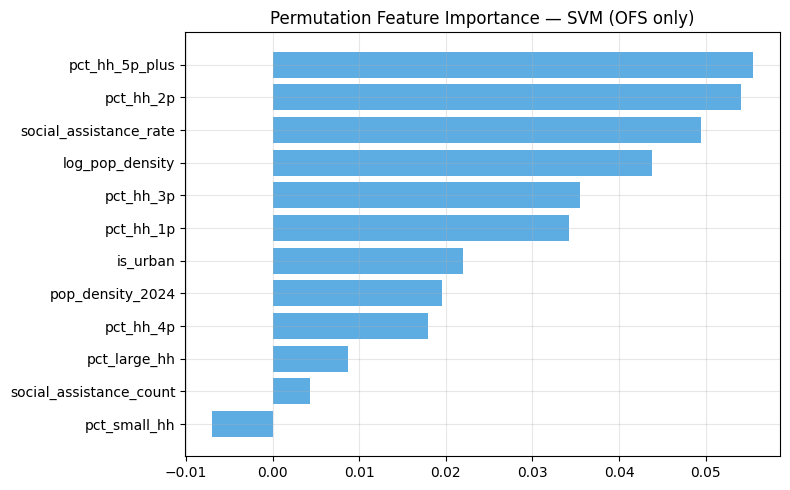

In [64]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(gs_svm_B.best_estimator_, X_te_ofs, y_test, n_repeats=10, random_state=42)
pi = pd.Series(perm.importances_mean, index=FEATURES_OFS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(pi.index, pi.values, color='#3498db', alpha=0.8)
ax.set_title('Permutation Feature Importance — SVM (OFS only)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

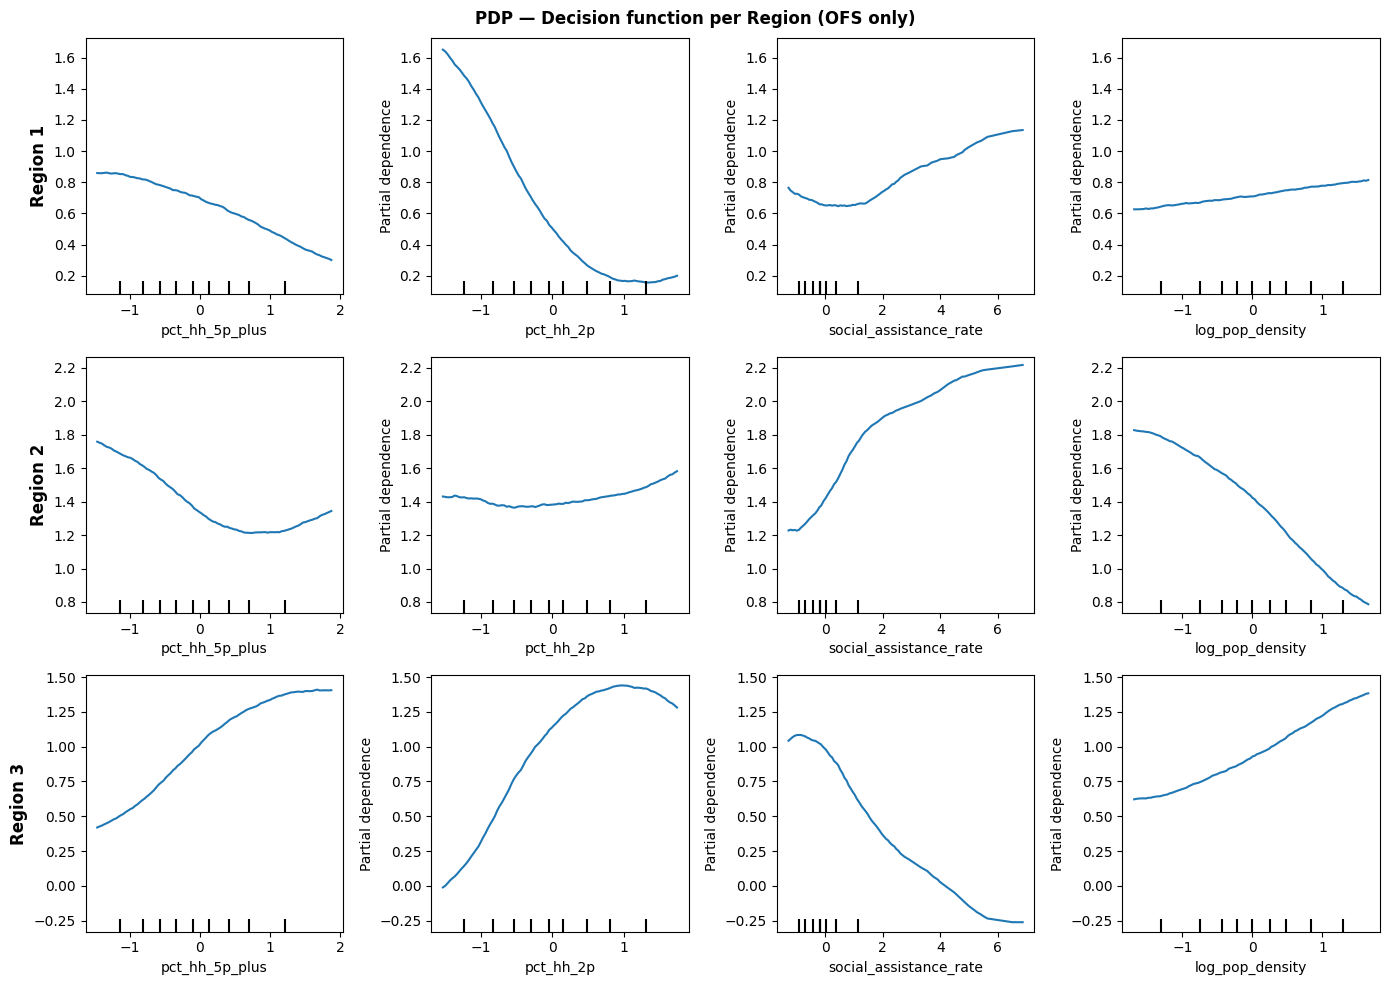

In [73]:
from sklearn.inspection import PartialDependenceDisplay

top_features = ['pct_hh_5p_plus', 'pct_hh_2p', 'social_assistance_rate', 'log_pop_density']
feature_idx = [list(FEATURES_OFS).index(f) for f in top_features]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, region in enumerate([1, 2, 3]):
    PartialDependenceDisplay.from_estimator(
        gs_svm_B.best_estimator_,
        X_tr_ofs,
        features=feature_idx,
        feature_names=list(FEATURES_OFS),
        target=region,
        ax=axes[i]
    )
    axes[i][0].set_ylabel(f'Region {region}', fontsize=12, fontweight='bold')

plt.suptitle('PDP — Decision function per Region (OFS only)', fontweight='bold')
plt.tight_layout()
plt.show()

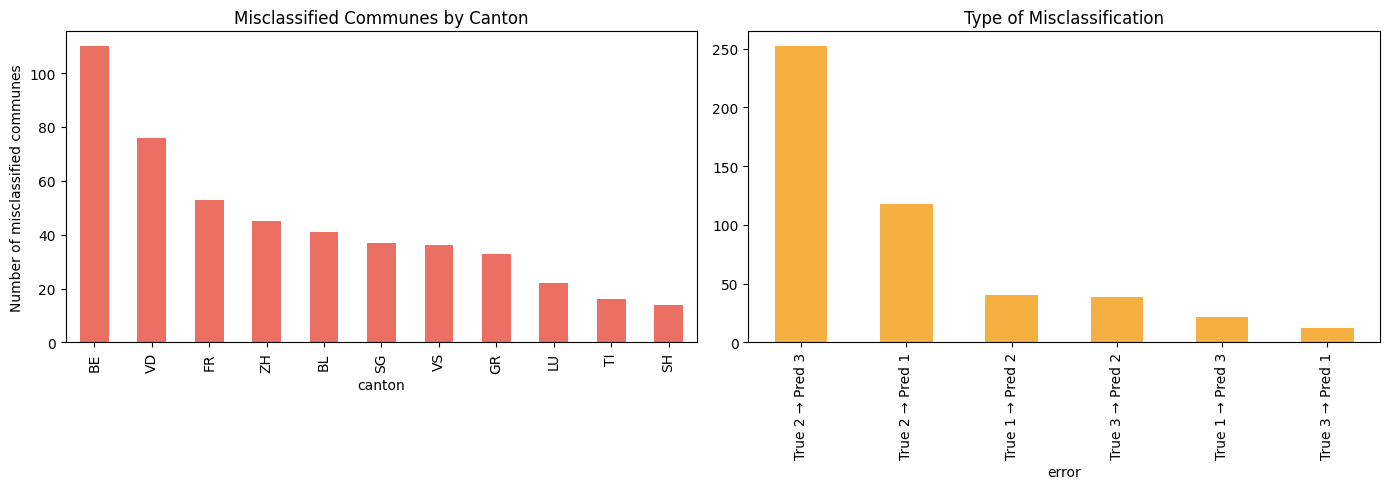

In [66]:
## Identification of misclassified

misclassified = df.copy()
misclassified['predicted'] = gs_svm_B.predict(sc_ofs.transform(df[FEATURES_OFS].values))
misclassified['correct'] = misclassified['predicted'] == misclassified['premium_region']
misclassified['error'] = misclassified.apply(
    lambda r: f"True {r['premium_region']} → Pred {r['predicted']}" if not r['correct'] else 'Correct', axis=1
)

canton_errors = misclassified[~misclassified['correct']].groupby('canton').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
canton_errors.plot(kind='bar', ax=axes[0], color='#e74c3c', alpha=0.8)
axes[0].set_title('Misclassified Communes by Canton')
axes[0].set_ylabel('Number of misclassified communes')

error_types = misclassified[~misclassified['correct']]['error'].value_counts()
error_types.plot(kind='bar', ax=axes[1], color='#f39c12', alpha=0.8)
axes[1].set_title('Type of Misclassification')

plt.tight_layout()
plt.show()

In [68]:
_, _, idx_train, idx_test = train_test_split(
    np.arange(len(df)), np.arange(len(df)),
    test_size=0.20, random_state=42, stratify=df['premium_region'].values
)
df_test = df.iloc[idx_test].copy()
df_test['y_pred'] = y_pred_svm_B

# Communes officially Region 1 but predicted as Region 3
r3_avg = df[df['premium_region'] == 3]['avg_premium_2026'].mean()
flagged = df_test[
    (df_test['premium_region'] == 1) & (df_test['y_pred'] == 3)
][['commune_ofs', 'canton', 'avg_premium_2026']].copy()

flagged['monthly_surplus_chf'] = (flagged['avg_premium_2026'] - r3_avg).round(1)
flagged['annual_surplus_chf']  = (flagged['monthly_surplus_chf'] * 12).round(0).astype(int)

print(f'Communes officially Region 1 predicted as Region 3: {len(flagged)}')
print(f'Avg monthly surplus: CHF {flagged["monthly_surplus_chf"].mean():.1f}')
print(f'Avg annual surplus:  CHF {flagged["annual_surplus_chf"].mean():.0f}')
print()
print(flagged.sort_values('annual_surplus_chf', ascending=False).to_string(index=False))

Communes officially Region 1 predicted as Region 3: 9
Avg monthly surplus: CHF 125.8
Avg annual surplus:  CHF 1510

       commune_ofs canton  avg_premium_2026  monthly_surplus_chf  annual_surplus_chf
          Brissago     TI             720.9                195.4                2345
Ronco sopra Ascona     TI             720.9                195.4                2345
            Jongny     VD             678.1                152.6                1831
            Vinzel     VD             678.1                152.6                1831
           Allaman     VD             678.1                152.6                1831
       Biel-Benken     BL             664.1                138.6                1663
           Autigny     FR             590.0                 64.5                 774
           Leytron     VS             565.9                 40.4                 485
         Veysonnaz     VS             565.9                 40.4                 485


In [70]:
print(classification_report(y_test, y_pred_svm_B, target_names=['Region 1', 'Region 2', 'Region 3']))

              precision    recall  f1-score   support

    Region 1       0.54      0.68      0.60        66
    Region 2       0.74      0.44      0.56       165
    Region 3       0.43      0.74      0.55        70

    accuracy                           0.56       301
   macro avg       0.57      0.62      0.57       301
weighted avg       0.63      0.56      0.56       301

